In [1]:



from model.models import *
from utils import *

from torch_geometric.utils import to_dense_adj

In [2]:

from visualize import visualize_cfs
dataset_name = 'mutag'

clf_model = GCN(14,2)          # load clf
#checkpoint = torch.load(f'model/pretrained/clf-{dataset_name}.pth')
checkpoint = torch.load(f'model/pretrained/{dataset_name}_proxy')
clf_model.load_state_dict(checkpoint['model_state_dict'])
clf_model.eval()                                                           

dataset = get_dataset('../dataset', dataset_name)

dataset = dataset.data_list
cnt = 0
indices = []
for i, data in enumerate(dataset):
    if data.y == 0:
        cnt += 1
        indices.append(i)
print(cnt)




#train_loader, val_loader, test_loader = get_dataloaders(data, args, batch_size=64, val_split=0.1, test_split=0.1)

1015


In [11]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import subgraph, to_networkx
import networkx as nx

import sys
!{sys.executable} -m pip install rdkit
from rdkit import Chem

def visualize_a_graph(edge_index, edge_att, node_label, dataset_name, coor=None, norm=False, mol_type=None, nodesize=300):
    fig, ax = plt.subplots() 
    node_color = ['#29A329', 'lime', '#F0EA00',  'maroon', 'brown', '#E49D1C', '#4970C6', '#FF5357']
    element_idxs = {k: Chem.PeriodicTable.GetAtomicNumber(Chem.GetPeriodicTable(), v) for k, v in mol_type.items()}
    node_colors = [node_color[(v - 1) % len(node_color)] for k, v in element_idxs.items()]

    if norm:  # for better visualization
        edge_att = edge_att**10
        edge_att = (edge_att - edge_att.min()) / (edge_att.max() - edge_att.min() + 1e-6)


    data = Data(edge_index=edge_index, att=edge_att, y=node_label, num_nodes=node_label.size(0)).to('cpu')
    G = to_networkx(data, node_attrs=['y'], edge_attrs=['att'])

    # calculate Graph positions
    if coor is None:
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = {idx: each.tolist() for idx, each in enumerate(coor)}
    for source, target, data in G.edges(data=True):
        ax.annotate(
            '', xy=pos[target], xycoords='data', xytext=pos[source],
            textcoords='data', arrowprops=dict(
                arrowstyle="->" if dataset_name == 'Graph-SST2' else '-',
                lw=max(data['att'], 0) * 3,
                alpha=max(data['att'], 0),  # alpha control transparency
                color='black',  # color control color
                shrinkA=np.sqrt(nodesize) / 2.0 + 1,
                shrinkB=np.sqrt(nodesize) / 2.0 + 1,
                connectionstyle='arc3,rad=0.4' if dataset_name == 'Graph-SST2' else 'arc3'
            ))

    if mol_type is not None:
        #nx.draw_networkx_labels(G, pos, mol_type, ax=ax)
        nx.draw_networkx_labels(G, pos, labels={i: i for i in G.nodes()}, ax=ax)


    if dataset_name != 'Graph-SST2':
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=nodesize, ax=ax)
        nx.draw_networkx_edges(G, pos, width=1, edge_color='gray', arrows=False, alpha=0.1, ax=ax)
    else:
        nx.draw_networkx_edges(G, pos, width=1, edge_color='gray', arrows=False, alpha=0.1, ax=ax, connectionstyle='arc3,rad=0.4')


[notice] A new release of pip is available: 23.3.2 -> 24.2
[notice] To update, run: pip3 install --upgrade pip


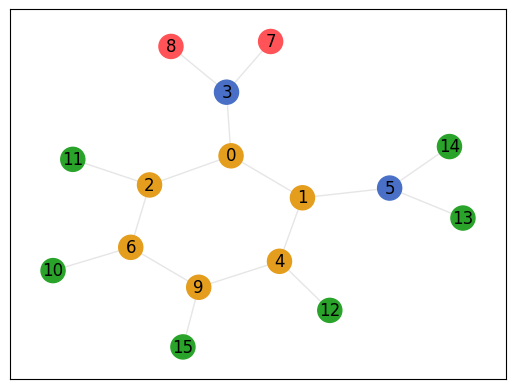

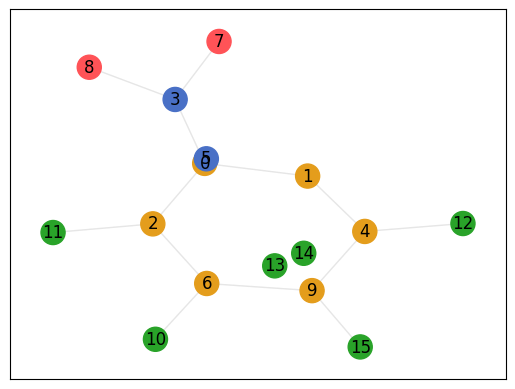

In [15]:

data = dataset[indices[20]]
x, edge_index, node_label, y = data.x ,data.edge_index, data.node_label, data.y
edge_att = torch.ones(edge_index.size(1))

node_dict = {0: 'C', 1: 'O', 2: 'Cl', 3: 'H', 4: 'N', 5: 'F', 6: 'Br', 7: 'S', 8: 'P', 9: 'I', 10: 'Na', 11: 'K', 12: 'Li', 13: 'Ca'}
mol_type = {k: node_dict[v.item()] for k, v in enumerate(data.node_type)}


visualize_a_graph(edge_index, edge_att, node_label, dataset_name, norm=True, mol_type=mol_type, coor=None)

nodes_to_remove = torch.tensor([5, 14, 13])
mask = ~torch.isin(edge_index[0], nodes_to_remove) & ~torch.isin(edge_index[1], nodes_to_remove)

edge_index_cf = edge_index[:, mask]
visualize_a_graph(edge_index_cf, edge_att, node_label, dataset_name, norm=True, mol_type=mol_type, coor=None)




In [16]:
y_pred = clf_model(x, edge_index)
y_pred_cf = clf_model(x, edge_index_cf)

print(y)
print(y_pred)
print(y_pred_cf)

0.0
tensor([[ 0.7249, -0.9109]], grad_fn=<AddmmBackward0>)
tensor([[-0.1555, -0.0827]], grad_fn=<AddmmBackward0>)
